In [11]:
# ==========================================
# 1. CONFIGURATION & GLOBAL DATA LOAD
# ==========================================
import os
import re
import json
import numpy as np
import pandas as pd
import open3d as o3d
import matplotlib.pyplot as plt

# File paths and naming
EXPERIMENT = "test_10_realgrasp"
DATA_FOLDER = "workpiece31"           # Folder containing the point clouds and listed in the CSV
CAD_MODEL_DIR = "workpiece31"        # Folder containing the .stl feature models (e.g. workpiece31)

ENABLE_VISUALIZATION = True

# Set USE_GROUND_TRUTH = True to optimize using actual physical Chamfer Distances from metadata.csv
USE_GROUND_TRUTH = True
GT_CSV_PATH = f"processed_data/{EXPERIMENT}/metadata.csv"
if not os.path.exists(GT_CSV_PATH):
    GT_CSV_PATH = f"processed_data/{EXPERIMENT}/{DATA_FOLDER}/metadata.csv"

# Neural Network inference results (used when USE_GROUND_TRUTH = False)
CSV_PATH = "../../pointnet_pytorch_reflective/data/6_simulation_3/inference_results_moe.csv"

WORKPIECE_PATH = f"workpiece/{CAD_MODEL_DIR}/workpiece.stl"
POSES_PATH = f"viewpoints_candidate/testing_data/{EXPERIMENT}"

# The EXACT 40k points saved from 1_3_viewpoint_generation_manual
GLOBAL_PCD_PATH = f"viewpoints_candidate/testing_data/{EXPERIMENT}/pcd_all.pcd"
GLOBAL_COVERED_JSON = f"viewpoints_candidate/testing_data/{EXPERIMENT}/covered_indices.json"

# Optimization Settings
OPTIMIZATION_METHOD = "GREEDY"  # "GREEDY" or "GRASP"
GRASP_ITERATIONS = 10          # Number of sequences to generate
RCL_SIZE = 4                   # Top N candidates to pick randomly from (Cardinality-based RCL)

# Utility weights & Discretization
ALPHA = 0.7 # Coverability
BETA = 0.3  # Confidence
GAMMA = 0.1 # Submodular decay factor for Coverability
TOTAL_STEPS = 8  # Number of viewpoints to select
AXIS_SIZE = 20.0
NUM_BINS = 10
TOP_PERCENTILE_FILTER = 0.9 # Keep the top n% of viewpoints based on Score

# ==========================================
# 2. HELPER FUNCTIONS
# ==========================================
def make_arrow(direction='x', size=50.0, color=(0.6, 0.6, 0.6)):
    arrow = o3d.geometry.TriangleMesh.create_arrow(
        cylinder_radius=size * 0.05,
        cone_radius=size * 0.15,
        cylinder_height=size * 0.80,
        cone_height=size * 0.20,
        resolution=20,
    )
    if direction == 'x':
        R_align = arrow.get_rotation_matrix_from_xyz((0, np.pi / 2, 0))
        arrow.rotate(R_align, center=(0, 0, 0))
    arrow.paint_uniform_color(list(color))
    arrow.compute_vertex_normals()
    return arrow

def make_xz_arrows(transform=None, size=50.0, color=(0.6, 0.6, 0.6)):
    frame = make_arrow('x', size=size, color=color) + make_arrow('z', size=size, color=color)
    if transform is not None:
        frame.transform(transform)
    return frame

def load_viewpoint_poses_dict(folder_path):
    def extract_number(filename):
        match = re.search(r'viewpoint_pose_(\d+)\.npy', filename)
        return int(match.group(1)) if match else -1
    
    npy_files = [f for f in os.listdir(folder_path) if f.endswith('.npy')]
    poses = {}
    for f in npy_files:
        idx = extract_number(f)
        if idx != -1:
            poses[idx] = np.load(os.path.join(folder_path, f))
    return poses

# ==========================================
# 3. LOAD GLOBAL DATA & MULTIPLE FEATURES
# ==========================================
print("Loading Global 40k Point Cloud...")
pcd_all = o3d.io.read_point_cloud(GLOBAL_PCD_PATH) if os.path.exists(GLOBAL_PCD_PATH) else o3d.geometry.PointCloud()
pcd_all.paint_uniform_color([0.6, 0.6, 0.6])
print(f"  - Loaded {len(pcd_all.points)} points from: {GLOBAL_PCD_PATH}")

print("\nLoading Global Viewpoint Visibilities...")
if os.path.exists(GLOBAL_COVERED_JSON):
    with open(GLOBAL_COVERED_JSON, "r") as f:
        global_visibility_dict = json.load(f)
    print(f"  - Loaded {len(global_visibility_dict)} viewpoints visibility mapping")
else:
    global_visibility_dict = {}
    print(f"  - WARNING: {GLOBAL_COVERED_JSON} not found!")

poses_dict = load_viewpoint_poses_dict(POSES_PATH)
print(f"\nLoaded {len(poses_dict)} viewpoint camera poses from: {POSES_PATH}")

# Check bounding box alignment between pcd_all and workpiece CAD mesh
cad_offset = np.zeros(3)
if os.path.exists(WORKPIECE_PATH) and len(pcd_all.points) > 0:
    wp_mesh = o3d.io.read_triangle_mesh(WORKPIECE_PATH)
    bbox_pcd = pcd_all.get_axis_aligned_bounding_box()
    bbox_mesh = wp_mesh.get_axis_aligned_bounding_box()
    cad_offset = bbox_pcd.get_center() - bbox_mesh.get_center()
    if np.linalg.norm(cad_offset) > 1e-3:
        print(f"  - Auto-aligned CAD origin offset: {np.round(cad_offset, 2)} mm")

# Load Inference Results CSV and parse Filename column
if USE_GROUND_TRUTH:
    df_inference = pd.read_csv(GT_CSV_PATH)
    df_inference.rename(columns={'filename': 'Filename', 'chamfer_value': 'Predicted_CD'}, inplace=True)
    print(f"\n--- USING GROUND TRUTH DATA FROM {GT_CSV_PATH} ---")
else:
    df_inference = pd.read_csv(CSV_PATH)
    print(f"\n--- USING PREDICTED DATA FROM {CSV_PATH} ---")
df_inference[['Parsed_Folder', 'Viewpoint', 'Feature']] = df_inference['Filename'].str.extract(r'(.*?)/viewpoint_simulated_(\d+)_(.*?)\.pcd')
df_inference['Viewpoint'] = df_inference['Viewpoint'].astype(int)

# Filter for the requested workpiece folder
df_chamfer = df_inference[df_inference['Parsed_Folder'] == DATA_FOLDER].copy()
df_chamfer.rename(columns={'Predicted_CD': 'Chamfer_Distance_mm'}, inplace=True)

# Calculate Global Normalized Feature Confidence
min_cd = df_chamfer[df_chamfer['Chamfer_Distance_mm'] >= 0]['Chamfer_Distance_mm'].min()
max_cd = df_chamfer['Chamfer_Distance_mm'].max()
if max_cd > min_cd:
    df_chamfer['Feature_Confidence'] = 1.0 - ((df_chamfer['Chamfer_Distance_mm'] - min_cd) / (max_cd - min_cd))
else:
    df_chamfer['Feature_Confidence'] = 1.0

features = list(df_chamfer['Feature'].unique())
if 'background' not in features:
    features.append('background')
print(f"\nFound {len(features)} unique features to optimize for {DATA_FOLDER}: {features}")

feature_indices = {}
all_features_indices = set()

# 1. Load all features simultaneously (supports both feature*.stl and surface*.stl)
feature_pcds = []
feature_names = []
for feat in features:
    feat_path = f"workpiece/{CAD_MODEL_DIR}/{feat}.stl"
    if not os.path.exists(feat_path):
        alt_feat = feat.replace('feature', 'surface') if 'feature' in feat else feat.replace('surface', 'feature')
        alt_path = f"workpiece/{CAD_MODEL_DIR}/{alt_feat}.stl"
        if os.path.exists(alt_path):
            feat_path = alt_path
    if os.path.exists(feat_path):
        f_mesh = o3d.io.read_triangle_mesh(feat_path)
        if np.linalg.norm(cad_offset) > 1e-3:
            f_mesh.translate(cad_offset)
        f_pcd = f_mesh.sample_points_poisson_disk(number_of_points=10000)
        feature_pcds.append(f_pcd)
        feature_names.append(feat)
    else:
        print(f"  - WARNING: {feat_path} not found!")

# 2. Voronoi Nearest-Neighbor Competition
if len(feature_pcds) > 0 and len(pcd_all.points) > 0:
    dists = np.zeros((len(pcd_all.points), len(feature_pcds)))
    for i, f_pcd in enumerate(feature_pcds):
        dists[:, i] = np.asarray(pcd_all.compute_point_cloud_distance(f_pcd))
    
    # 3. Populate feature indices
    assignments = np.argmin(dists, axis=1)
    for i, feat in enumerate(feature_names):
        if feat == 'background':
            continue
        idx_set = set(np.where(assignments == i)[0])
        feature_indices[feat] = idx_set
        all_features_indices.update(idx_set)
        print(f"  - {feat}: {len(idx_set)} matching points in 40k cloud (Voronoi Assignment)")
else:
    print("WARNING: No valid features or empty global point cloud!")

print(f"\nTotal target points across all features: {len(all_features_indices)}")


Loading Global 40k Point Cloud...
  - Loaded 40000 points from: viewpoints_candidate/testing_data/test_10_realgrasp/pcd_all.pcd

Loading Global Viewpoint Visibilities...
  - Loaded 288 viewpoints visibility mapping

Loaded 287 viewpoint camera poses from: viewpoints_candidate/testing_data/test_10_realgrasp
  - Auto-aligned CAD origin offset: [  0.    0.  -11.2] mm

--- USING GROUND TRUTH DATA FROM processed_data/test_10_realgrasp/metadata.csv ---

Found 5 unique features to optimize for workpiece31: ['surface0', 'surface1', 'surface2', 'surface3', 'background']
  - surface0: 5824 matching points in 40k cloud (Voronoi Assignment)
  - surface1: 1725 matching points in 40k cloud (Voronoi Assignment)
  - surface2: 7825 matching points in 40k cloud (Voronoi Assignment)
  - surface3: 15715 matching points in 40k cloud (Voronoi Assignment)

Total target points across all features: 31089


In [12]:
# ==========================================
# 4. OPTIMIZATION RUN (GREEDY / GRASP)
# ==========================================
import pandas as pd
import numpy as np
import random

if OPTIMIZATION_METHOD == "GREEDY":
    num_iterations = 1
    rcl_size = 1
else:
    num_iterations = GRASP_ITERATIONS
    rcl_size = RCL_SIZE

if len(all_features_indices) == 0:
    print("WARNING: all_features_indices is empty. Make sure you loaded the data correctly.")

print(f"Starting {OPTIMIZATION_METHOD} Optimization for {TOTAL_STEPS} steps...")
if OPTIMIZATION_METHOD == "GRASP":
    print(f"Running {num_iterations} iterations with RCL Size = {rcl_size} (Cardinality)...\n")

# Global tracking for the absolute best sequence found
best_overall_sequence = []
best_overall_score = -1.0
best_overall_point_counts = None
best_step_to_covered = {}
best_all_step_results = []

# --- PRECOMPUTE STATIC CHAMFER DATA ---
print("Precomputing static viewpoint data (Dynamic Filter)...")
total_object_points = len(all_features_indices)
static_viewpoint_data = {}
temp_cameras = []

for v_idx, group in df_chamfer.groupby('Viewpoint'):
    v_idx = int(v_idx)
    if v_idx not in poses_dict or pd.isna(group['Chamfer_Distance_mm'].iloc[0]): continue
    
    camera_visible_40k = set(global_visibility_dict.get(str(v_idx), []))
    
    camera_target_indices = set()
    sum_weighted_chamfer = 0.0
    sum_points = 0
    
    for _, row in group.iterrows():
        feature = row['Feature']
        chamfer_dist = row['Chamfer_Distance_mm']
        if feature not in feature_indices: continue
            
        feat_visible_points = camera_visible_40k & feature_indices[feature]
        P_vj = len(feat_visible_points)
        if P_vj == 0: continue
            
        camera_target_indices.update(feat_visible_points)
        sum_weighted_chamfer += (P_vj * chamfer_dist)
        sum_points += P_vj
        
    if sum_points == 0: continue
        
    weighted_chamfer = sum_weighted_chamfer / sum_points
    
    temp_cameras.append({
        'v_idx': v_idx,
        'weighted_chamfer': weighted_chamfer,
        'visible_target_indices': camera_target_indices,
        'sum_points': sum_points
    })

# Normalize and Score
if len(temp_cameras) > 0:
    min_cam_cd = min(c['weighted_chamfer'] for c in temp_cameras)
    max_cam_cd = max(c['weighted_chamfer'] for c in temp_cameras)
    
    for c in temp_cameras:
        if max_cam_cd > min_cam_cd:
            c['confidence'] = 1.0 - ((c['weighted_chamfer'] - min_cam_cd) / (max_cam_cd - min_cam_cd))
        else:
            c['confidence'] = 1.0
            
        c['filter_score'] = (c['sum_points'] / total_object_points) * c['confidence']
        
    # Sort by Filter Score (Highest to Lowest)
    temp_cameras.sort(key=lambda x: x['filter_score'], reverse=True)
    num_to_keep = max(1, int(len(temp_cameras) * TOP_PERCENTILE_FILTER))
    top_cameras = temp_cameras[:num_to_keep]
    
    for c in top_cameras:
        static_viewpoint_data[c['v_idx']] = {
            'weighted_chamfer': c['weighted_chamfer'],
            'visible_target_indices': c['visible_target_indices'],
            'idx_arr': list(c['visible_target_indices'])
        }
    print(f"Filtered to Top {TOP_PERCENTILE_FILTER*100}% cameras ({len(static_viewpoint_data)}/{len(temp_cameras)} cameras).")
else:
    print("No valid cameras found!")

for iteration in range(1, num_iterations + 1):
    
    # State is completely reset at the start of every sequence generation
    point_coverage_counts = np.zeros(len(pcd_all.points))
    selected_viewpoints = []
    step_to_covered_indices = {}
    all_step_results = []
    
    cumulative_utility = 0.0
    
    for k in range(1, TOTAL_STEPS + 1):
        db_records = []
        
        for v_idx, data in static_viewpoint_data.items():
            if v_idx in selected_viewpoints:
                continue
                
            idx_arr = data['idx_arr']
            c_vals = point_coverage_counts[idx_arr]
            submodular_sum = np.sum(GAMMA ** c_vals)
            coverability = submodular_sum / len(all_features_indices)
            
            # Vectorized newly covered calculation
            newly_covered_arr = np.array(idx_arr)[c_vals == 0]
            newly_covered = newly_covered_arr.tolist()
            
            db_records.append({
                'Step': k,
                'Viewpoint': v_idx,
                'Coverability': coverability,
                'Chamfer_Distance': data['weighted_chamfer'],
                '_visible_target_indices': data['visible_target_indices'],
                '_new_points_set': newly_covered
            })
        
        df_step = pd.DataFrame(db_records)
        if df_step.empty:
            break
            
        # --- Normalize Metrics ---
        min_cov = df_step['Coverability'].min()
        max_cov = df_step['Coverability'].max()
        df_step['Norm_Coverability'] = (df_step['Coverability'] - min_cov) / (max_cov - min_cov) if max_cov > min_cov else 1.0
        
        # --- Uncertainty & Confidence ---
        df_step['Uncertainty'] = df_step['Chamfer_Distance']
        min_uncert = df_step['Uncertainty'].min()
        max_uncert = df_step['Uncertainty'].max()
        df_step['Confidence'] = 1.0 - ((df_step['Uncertainty'] - min_uncert) / (max_uncert - min_uncert)) if max_uncert > min_uncert else 1.0
        
        # --- Utility Score ---
        df_step['Information_Gain'] = df_step['Norm_Coverability']
        df_step['Utility_Score'] = ALPHA * df_step['Information_Gain'] + BETA * df_step['Confidence']
        
        # Rank Candidates
        df_step = df_step.sort_values(by='Utility_Score', ascending=False).reset_index(drop=True)
        df_step['Rank'] = df_step.index + 1

        # (Optional) Print Top/Bottom Candidates (Only if running 1 iteration)
        if num_iterations == 1:
            print(f"\n--- STEP {k} CANDIDATE PREVIEW ---")
            display_cols = ['Rank', 'Viewpoint', 'Coverability', 'Chamfer_Distance', 'Utility_Score']
            print(f"Top 5 Candidates:")
            display(df_step.head(5)[display_cols])
            print(f"Bottom 5 Candidates:")
            display(df_step.tail(5)[display_cols])

        
        # --------------------------------------------------
        # RCL SELECTION (CARDINALITY)
        # --------------------------------------------------
        actual_rcl_size = min(rcl_size, len(df_step))
        rcl = df_step.head(actual_rcl_size)
        
        # Pick completely randomly from the RCL
        chosen_idx = random.randint(0, actual_rcl_size - 1)
        best_row = rcl.iloc[chosen_idx]
        
        all_step_results.append(best_row)
        
        best_v_idx = int(best_row['Viewpoint'])
        selected_viewpoints.append(best_v_idx)
        
        # Update state
        idx_arr = np.array(list(best_row['_visible_target_indices']), dtype=int)
        point_coverage_counts[idx_arr] += 1
        cumulative_utility += best_row['Utility_Score']
        
        step_to_covered_indices[k] = list(best_row['_visible_target_indices'])
    
    if cumulative_utility > best_overall_score:
        best_overall_score = cumulative_utility
        best_overall_sequence = list(selected_viewpoints)
        best_overall_point_counts = point_coverage_counts.copy()
        best_step_to_covered = dict(step_to_covered_indices)
        best_all_step_results = list(all_step_results)
        
    if OPTIMIZATION_METHOD == "GRASP":
        print(f"  Iteration {iteration}/{num_iterations} | Current Utility: {cumulative_utility:.4f} | Best Sum Utility: {best_overall_score:.4f}")

# --- FINAL RESULTS ---
selected_viewpoints = best_overall_sequence
point_coverage_counts = best_overall_point_counts
step_to_covered_indices = best_step_to_covered
all_step_results = best_all_step_results

print(f"\n{'='*50}")
print(f"Processing Workpiece: {DATA_FOLDER}")
print(f"{'='*50}")
print(f"Manual Viewpoint Sequence: {selected_viewpoints}\n")

table_data = []
for result in all_step_results:
    table_data.append({
        'Step': int(result['Step']),
        'Viewpoint': int(result['Viewpoint']),
        'Utility': result['Utility_Score'],
        'Cumulative Coverability': result['Coverability'],
        'Raw Error (mm)': result['Chamfer_Distance'],
        'Normalized Confidence': result['Confidence']
    })

df_table = pd.DataFrame(table_data)
df_table.set_index('Step', inplace=True)
from IPython.display import display
display(df_table)


Starting GREEDY Optimization for 8 steps...
Precomputing static viewpoint data (Dynamic Filter)...
Filtered to Top 90.0% cameras (257/286 cameras).

--- STEP 1 CANDIDATE PREVIEW ---
Top 5 Candidates:


,Rank,Viewpoint,Coverability,Chamfer_Distance,Utility_Score
0,1,213,0.439319,7.835265,0.870184
1,2,214,0.439384,7.928921,0.867333
2,3,54,0.439577,8.027696,0.864673
3,4,226,0.439866,8.053429,0.864643
4,5,135,0.439512,8.196174,0.859046


Bottom 5 Candidates:


,Rank,Viewpoint,Coverability,Chamfer_Distance,Utility_Score
252,253,207,0.187783,6.650980,0.211781
253,254,3,0.188137,6.955760,0.202904
254,255,201,0.187944,6.964719,0.202080
255,256,202,0.187976,7.508926,0.184569
256,257,198,0.187976,7.639400,0.180349



--- STEP 2 CANDIDATE PREVIEW ---
Top 5 Candidates:


...

,Rank,Viewpoint,Coverability,Chamfer_Distance,Utility_Score
0,1,238,0.000253,9.512567,0.719082
1,2,191,0.000288,12.127044,0.718631
2,3,237,0.000253,9.610374,0.715918
3,4,95,0.000295,13.147394,0.701684
4,5,223,0.000253,10.055434,0.701610


Bottom 5 Candidates:


,Rank,Viewpoint,Coverability,Chamfer_Distance,Utility_Score
245,246,195,0.000015,9.834243,0.142244
246,247,278,0.000036,11.491119,0.139198
247,248,184,0.000018,10.260276,0.137522
248,249,264,0.000018,10.846044,0.118502
249,250,280,0.000018,11.120421,0.109705



Processing Workpiece: workpiece31
Manual Viewpoint Sequence: [213, 221, 54, 222, 38, 239, 182, 238]



,Viewpoint,Utility,Cumulative Coverability,Raw Error (mm),Normalized Confidence
Step,,,,,
1,213,0.870184,0.439319,7.835265,0.578268
2,221,0.831308,0.271556,9.118924,0.439888
3,54,0.864771,0.027309,8.027696,0.557523
4,222,0.822162,0.025492,9.309417,0.419352
5,38,0.839180,0.002615,8.353050,0.522450
6,239,0.811285,0.002564,9.433848,0.405938
7,182,0.792303,0.000358,10.345361,0.307676
8,238,0.719082,0.000253,9.512567,0.397452


In [57]:
# ==========================================
# 5. VISUALIZATION COVERAGE PER VIEWPOINT
 # ==========================================
import copy
import matplotlib.pyplot as plt

# Create a copy of pcd_all to colorize
vis_pcd = copy.deepcopy(pcd_all)

# Default color (light gray) for unseen points
colors = np.ones((len(vis_pcd.points), 3)) * 0.8

# Generate distinct colors for each step (e.g. from tab10 colormap)
cmap = plt.get_cmap("tab10")

print("Point Colors:")
seen_so_far = set()
for k in range(1, TOTAL_STEPS + 1):
    if k in step_to_covered_indices:
        step_color = cmap(k - 1)[:3]  # RGB from colormap
        
        # Color text for the print statement using ANSI escape codes
        r, g, b = [int(c * 255) for c in step_color]
        colored_text = f"\033[38;2;{r};{g};{b}mStep {k}\033[0m"
        current_indices = set(step_to_covered_indices[k])
        new_indices = current_indices - seen_so_far
        new_points_count = len(new_indices)
        seen_so_far.update(current_indices)
        print(f"{colored_text} sees {len(current_indices)} points ({new_points_count}  are newly seen)")
        
        indices = list(step_to_covered_indices[k])
        colors[indices] = step_color

vis_pcd.colors = o3d.utility.Vector3dVector(colors)

# Draw geometries
print("\nOpening Open3D visualization window...")
if ENABLE_VISUALIZATION:
    o3d.visualization.draw_geometries(
        [vis_pcd], 
        window_name="Step-by-Step Coverage",
        width=1024, height=768,
        front=[0, 0, 1], lookat=[0, 0, 0], up=[0, 1, 0], zoom=1.0
    )


Point Colors:
Step 1 sees 5852 points (5852  are newly seen)
Step 2 sees 5852 points (2  are newly seen)
Step 3 sees 5849 points (1  are newly seen)
Step 4 sees 5848 points (0  are newly seen)

Opening Open3D visualization window...


In [53]:
# ==========================================
# 6. EXTRA: VISUALIZE ONLY DETECTED POINTS
# ==========================================
import open3d as o3d
import numpy as np

print("Filtering out unseen (grey) points...")

# Collect all indices of points covered in ANY step
all_covered_indices = set()
for step, indices in step_to_covered_indices.items():
    all_covered_indices.update(indices)

# Use Open3D's select_by_index to extract ONLY the colored points
covered_pcd = vis_pcd.select_by_index(list(all_covered_indices))

print(f"Total points shown: {len(covered_pcd.points)}")

# Draw geometries
print("\nOpening Open3D visualization window (Detected Points Only)...")
if ENABLE_VISUALIZATION:
    o3d.visualization.draw_geometries(
        [covered_pcd], 
        window_name="Detected Points Only",
        width=1024, height=768,
        front=[0, 0, 1], lookat=[0, 0, 0], up=[0, 1, 0], zoom=1.0
    )


Filtering out unseen (grey) points...
Total points shown: 17218

Opening Open3D visualization window (Detected Points Only)...


In [ ]:
# ==========================================
# 7. VISUALIZE SELECTED GRASP POSES
# ==========================================
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
import copy

vis_pcd = copy.deepcopy(pcd_all)

print("Generating visualization of the entire workpiece and camera poses...")

# We use the full workpiece (vis_pcd) instead of filtering it!
geometries = [vis_pcd]

cmap = plt.get_cmap("tab10")

print("\n--- Selected Viewpoints Summary ---")
# For each step, create the camera pose arrows matching the step color
for k, v_idx in enumerate(selected_viewpoints, 1):
    step_color = cmap(k - 1)[:3]
    
    # Print the summary
    r, g, b = [int(c * 255) for c in step_color]
    colored_text = f"\033[38;2;{r};{g};{b}mStep {k}\033[0m"
    print(f"{colored_text}: Viewpoint {v_idx}")
    
    # Add the colored pose arrows to the visualization
    if v_idx in poses_dict:
        pose_arrows = make_xz_arrows(transform=poses_dict[v_idx], size=AXIS_SIZE, color=step_color)
        geometries.append(pose_arrows)

print("\nOpening Open3D visualization window...")

if ENABLE_VISUALIZATION:
    o3d.visualization.draw_geometries(
        geometries, 
        window_name="Entire Workpiece and Camera Poses",
        width=1024, height=768,
        front=[0, 0, 1], lookat=[0, 0, 0], up=[0, 1, 0], zoom=1.0
    )


Generating visualization of the entire workpiece and camera poses...

--- Selected Viewpoints Summary ---
Step 1: Viewpoint 213
Step 2: Viewpoint 221
Step 3: Viewpoint 54
Step 4: Viewpoint 222
Step 5: Viewpoint 38
Step 6: Viewpoint 239
Step 7: Viewpoint 182
Step 8: Viewpoint 238

Opening Open3D visualization window...


: 

In [7]:
vis_pcd

PointCloud with 40000 points.

In [23]:
# ==========================================
# 8. STEP-BY-STEP OBSERVATION FREQUENCY
# ==========================================
import copy
import matplotlib.pyplot as plt
import open3d as o3d
import numpy as np

print("Generating progressive observation frequency visualizations...")
cmap = plt.get_cmap("tab10")

# We will simulate the frequency accumulation step-by-step
current_counts = np.zeros(len(pcd_all.points))

for k, v_idx in enumerate(selected_viewpoints, 1):
    print(f"\n{'='*40}")
    print(f" STEP {k} FREQUENCY STATE (After adding Viewpoint {v_idx})")
    print(f"{'='*40}")
    
    # 1. Fetch the exact points seen by this specific viewpoint
    camera_visible_40k = set(global_visibility_dict.get(str(v_idx), []))
    visible_target_indices = camera_visible_40k & all_features_indices
    
    # 2. Add them to our cumulative counts
    for idx in visible_target_indices:
        current_counts[idx] += 1
        
    # 3. Create point cloud for this step
    freq_pcd = copy.deepcopy(pcd_all)
    colors = np.ones((len(freq_pcd.points), 3)) * 0.8
    
    max_obs = int(np.max(current_counts))
    for count in range(1, max_obs + 1):
        indices = np.where(current_counts == count)[0]
        if len(indices) > 0:
            freq_color = cmap(count - 1)[:3]
            r, g, b = [int(c * 255) for c in freq_color]
            colored_text = f"\033[38;2;{r};{g};{b}mSeen {count} Time(s)\033[0m"
            print(f"{colored_text}: {len(indices)} points")
            colors[indices] = freq_color
            
    freq_pcd.colors = o3d.utility.Vector3dVector(colors)
    
    # 4. Filter out unseen points (0 count)
    observed_indices = np.where(current_counts > 0)[0]
    covered_freq_pcd = freq_pcd.select_by_index(list(observed_indices))
    
    print(f"Opening Open3D visualization window for Step {k}...")
    print("NOTE: Close the Open3D window to proceed to the next step!")
    
    o3d.visualization.draw_geometries(
        [covered_freq_pcd], 
        window_name=f"Observation Frequency (After Step {k})",
        width=1024, height=768,
        front=[0, 0, 1], lookat=[0, 0, 0], up=[0, 1, 0], zoom=1.0
    )


Generating progressive observation frequency visualizations...

 STEP 1 FREQUENCY STATE (After adding Viewpoint 231)
Seen 1 Time(s): 11560 points
Opening Open3D visualization window for Step 1...
NOTE: Close the Open3D window to proceed to the next step!

 STEP 2 FREQUENCY STATE (After adding Viewpoint 221)
Seen 1 Time(s): 11442 points
Seen 2 Time(s): 5824 points
Opening Open3D visualization window for Step 2...
NOTE: Close the Open3D window to proceed to the next step!

 STEP 3 FREQUENCY STATE (After adding Viewpoint 215)
Seen 1 Time(s): 5705 points
Seen 2 Time(s): 5739 points
Seen 3 Time(s): 5823 points
Opening Open3D visualization window for Step 3...
NOTE: Close the Open3D window to proceed to the next step!

 STEP 4 FREQUENCY STATE (After adding Viewpoint 239)
Seen 1 Time(s): 1 points
Seen 2 Time(s): 11437 points
Seen 3 Time(s): 7 points
Seen 4 Time(s): 5822 points
Opening Open3D visualization window for Step 4...
NOTE: Close the Open3D window to proceed to the next step!

 STEP 5

In [84]:
# ==========================================
# 9. ENTIRE POSE AND CONFIDENCE VISUALIZATION
# ==========================================
import os
import re
import numpy as np
import pandas as pd
import open3d as o3d
import matplotlib.pyplot as plt

# 1. HELPER FUNCTIONS
def make_arrow(direction='x', size=50.0, color=(0.6, 0.6, 0.6)):
    arrow = o3d.geometry.TriangleMesh.create_arrow(
        cylinder_radius=size * 0.05,
        cone_radius=size * 0.15,
        cylinder_height=size * 0.80,
        cone_height=size * 0.20,
        resolution=20,
    )
    if direction == 'x':
        R_align = arrow.get_rotation_matrix_from_xyz((0, np.pi / 2, 0))
        arrow.rotate(R_align, center=(0, 0, 0))
    arrow.paint_uniform_color(list(color))
    arrow.compute_vertex_normals()
    return arrow

def make_xz_arrows(transform=None, size=50.0, color=(0.6, 0.6, 0.6)):
    frame = make_arrow('x', size=size, color=color) + make_arrow('z', size=size, color=color)
    if transform is not None:
        frame.transform(transform)
    return frame

def visualize_viewpoints_colored(meshes, matrices, colors_per_frame, axis_size=50.0):
    if isinstance(matrices, np.ndarray) and matrices.ndim == 2:
        matrices = [matrices]

    geometries = list(meshes)
    geometries.append(make_xz_arrows(transform=None, size=axis_size, color=(0.9, 0.9, 0.9)))

    for i, (mat, color) in enumerate(zip(matrices, colors_per_frame)):
        geometries.append(make_xz_arrows(transform=mat, size=axis_size, color=color))

    print(f"\nVisualizing {len(matrices)} viewpoint(s)...")
    if ENABLE_VISUALIZATION:
        o3d.visualization.draw_geometries(
            geometries,
            window_name="Optimization Results & Viewpoint Visualization",
            width=1024, height=768,
            front=[0, 0, 1], lookat=[0, 0, 0], up=[0, 1, 0], zoom=1.0
        )

# 2. LOAD MESH / PCD
# We will just use `pcd_all` from the optimization block!
if 'pcd_all' not in locals() or len(pcd_all.points) == 0:
    print("Warning: pcd_all is empty. Run the optimization block first.")
    workpiece_pcd = o3d.geometry.PointCloud()
else:
    workpiece_pcd = pcd_all
    workpiece_pcd.paint_uniform_color([0.6, 0.6, 0.6])

# 3. POINT-WEIGHTED CONFIDENCE (FROM OPTIMIZER)
if 'static_viewpoint_data' not in locals() or len(static_viewpoint_data) == 0:
    print("Warning: static_viewpoint_data is empty. Please run the Optimization block first!")
    df_avg_conf = pd.DataFrame(columns=['Viewpoint', 'Feature_Confidence'])
else:
    records = []
    for v_idx, data in static_viewpoint_data.items():
        records.append({
            'Viewpoint': v_idx,
            'Chamfer_Distance_mm': data['weighted_chamfer']
        })
    df_avg_conf = pd.DataFrame(records)
    
    min_cd = df_avg_conf['Chamfer_Distance_mm'].min()
    max_cd = df_avg_conf['Chamfer_Distance_mm'].max()
    if max_cd > min_cd:
        df_avg_conf['Feature_Confidence'] = 1.0 - ((df_avg_conf['Chamfer_Distance_mm'] - min_cd) / (max_cd - min_cd))
    else:
        df_avg_conf['Feature_Confidence'] = 1.0

# 4. COLOR PROCESSING (NUM_BINS)
if not df_avg_conf.empty:
    _cmap = plt.get_cmap('coolwarm')
    CLASS_COLORS = {cls: tuple(_cmap(cls / (NUM_BINS - 1))[:3]) for cls in range(NUM_BINS)}
    
    # Handle edge case where all confidences are identical
    if df_avg_conf['Feature_Confidence'].nunique() > 1:
        _, bins = pd.cut(df_avg_conf['Feature_Confidence'], bins=NUM_BINS, retbins=True)
        df_avg_conf['Confidence_Class'] = pd.cut(
            df_avg_conf['Feature_Confidence'], bins=bins, labels=range(NUM_BINS), include_lowest=True
        )
    else:
        df_avg_conf['Confidence_Class'] = NUM_BINS - 1
    
    valid_poses = []
    colors_per_frame = []
    
    for _, row in df_avg_conf.iterrows():
        v_idx = int(row['Viewpoint'])
        
        if v_idx in poses_dict and pd.notna(row['Confidence_Class']):
            # Skip drawing the cool/warm arrow if it's our optimal green arrow (prevents Z-fighting glitch)
            if 'selected_viewpoints' in locals() and v_idx in selected_viewpoints:
                continue
            valid_poses.append(poses_dict[v_idx])
            colors_per_frame.append(CLASS_COLORS[int(row['Confidence_Class'])])

    print(f"\nVisualizing {len(valid_poses)} valid viewpoints that passed the threshold filter.")
    print(f"Average Point-Weighted Confidence range: {df_avg_conf['Feature_Confidence'].min():.2f} - {df_avg_conf['Feature_Confidence'].max():.2f}")

    # --- HIGHLIGHT THE OPTIMAL SEQUENCE ---
    # Overwrite the colors of the chosen sequence to Bright Green so they stand out!
    # if 'selected_viewpoints' in locals() and selected_viewpoints:
    #     print(f"Highlighting Optimal Sequence in Bright Green: {selected_viewpoints}")
    #     for v_idx in selected_viewpoints:
    #         if v_idx in poses_dict:
    #             valid_poses.append(poses_dict[v_idx])
    #             colors_per_frame.append((0.0, 1.0, 0.0))

    # 5. SHOW RESULTS
    if valid_poses:
        visualize_viewpoints_colored([workpiece_pcd], valid_poses, colors_per_frame, axis_size=AXIS_SIZE)
    else:
        print("No valid viewpoint poses to visualize.")



Visualizing 384 valid viewpoints that passed the threshold filter.
Average Point-Weighted Confidence range: 0.00 - 1.00

Visualizing 384 viewpoint(s)...


Visualizing Raw Confidence for feature1...

Visualizing 96 viewpoints looking at feature1.
Raw Chamfer Distance range (capped): 3.50mm - 5.43mm


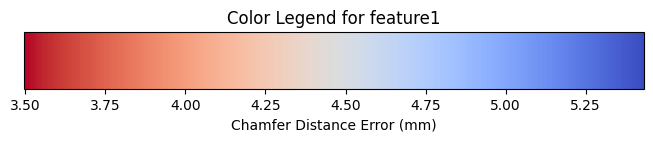


Visualizing 96 viewpoint(s)...


In [97]:
# ==========================================
# 10. VISUALIZE CONFIDENCE FOR A SINGLE FEATURE
# ==========================================
import os
import numpy as np
import pandas as pd
import open3d as o3d
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
TARGET_VIS_FEATURE = "feature1"
VIEWPOINT_RANGE = (0, 95)  # Only visualize viewpoints within this ID range (inclusive)
# ---------------------

print(f"Visualizing Raw Confidence for {TARGET_VIS_FEATURE}...")

# 1. LOAD MESH / PCD
if 'pcd_all' not in locals() or len(pcd_all.points) == 0:
    print("Warning: pcd_all is empty. Run the optimization block first.")
    workpiece_pcd = o3d.geometry.PointCloud()
else:
    workpiece_pcd = pcd_all
    workpiece_pcd.paint_uniform_color([0.6, 0.6, 0.6])

# 2. FILTER DATA FOR SPECIFIC FEATURE
if 'df_chamfer' not in locals():
    print("Warning: df_chamfer not found. Run Block 1 first!")
else:
    df_feat = df_chamfer[df_chamfer['Feature'] == TARGET_VIS_FEATURE].copy()
    df_feat = df_feat[(df_feat['Viewpoint'] >= VIEWPOINT_RANGE[0]) & (df_feat['Viewpoint'] <= VIEWPOINT_RANGE[1])]
    
    if df_feat.empty:
        print(f"Warning: No data found for feature '{TARGET_VIS_FEATURE}' in metadata.csv!")
    else:
        # Cap extreme outliers at 95th percentile so the color gradient doesn't wash out
        cap_val = df_feat['Chamfer_Distance_mm'].quantile(0.95)
        df_feat['Capped_Chamfer'] = df_feat['Chamfer_Distance_mm'].clip(upper=cap_val)
        
        min_cd = df_feat['Capped_Chamfer'].min()
        max_cd = df_feat['Capped_Chamfer'].max()
        
        if max_cd > min_cd:
            df_feat['Feature_Confidence'] = 1.0 - ((df_feat['Capped_Chamfer'] - min_cd) / (max_cd - min_cd))
        else:
            df_feat['Feature_Confidence'] = 1.0

        # 3. COLOR PROCESSING
        _cmap = plt.get_cmap('coolwarm')
        CLASS_COLORS = {cls: tuple(_cmap(cls / (NUM_BINS - 1))[:3]) for cls in range(NUM_BINS)}
        
        if df_feat['Feature_Confidence'].nunique() > 1:
            _, bins = pd.cut(df_feat['Feature_Confidence'], bins=NUM_BINS, retbins=True)
            df_feat['Confidence_Class'] = pd.cut(
                df_feat['Feature_Confidence'], bins=bins, labels=range(NUM_BINS), include_lowest=True
            )
        else:
            df_feat['Confidence_Class'] = NUM_BINS - 1
            
        valid_poses = []
        colors_per_frame = []
        
        for _, row in df_feat.iterrows():
            v_idx = int(row['Viewpoint'])
            
            if v_idx in poses_dict and pd.notna(row['Confidence_Class']):
                valid_poses.append(poses_dict[v_idx])
                colors_per_frame.append(CLASS_COLORS[int(row['Confidence_Class'])])
                
        print(f"\nVisualizing {len(valid_poses)} viewpoints looking at {TARGET_VIS_FEATURE}.")
        print(f"Raw Chamfer Distance range (capped): {min_cd:.2f}mm - {max_cd:.2f}mm")
        
        # --- DRAW COLORBAR LEGEND ---
        fig, ax = plt.subplots(figsize=(1.5, 5))
        fig.subplots_adjust(left=0.1, right=0.3)
        norm = plt.Normalize(vmin=0, vmax=1)
        cb = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=_cmap), cax=ax, orientation='vertical')
        cb.set_ticks([0, 1])
        cb.set_ticklabels(['Worst Accuracy\n(High CD)', 'Best Accuracy\n(Low CD)'])
        plt.title(f"Confidence", pad=20)
        plt.show()


        if valid_poses:
            # Uses visualize_viewpoints_colored from Block 9
            visualize_viewpoints_colored([workpiece_pcd], valid_poses, colors_per_frame, axis_size=AXIS_SIZE)
        else:
            print("No valid viewpoint poses to visualize.")


### 10. Batch Processing (Multiple Workpieces)
Run the optimization pipeline automatically across an entire list of workpieces.

In [45]:
# ==========================================
# BATCH PROCESSING MULTIPLE WORKPIECES
# ==========================================
import os
import re
import json
import numpy as np
import pandas as pd
import open3d as o3d
import random
import time
    
# ------------------------------------------
# BATCH CONFIGURATION
# ------------------------------------------
# BATCH_WORKPIECES = ["TH0011AV"]  # Add as many as you want to test
BATCH_WORKPIECES = ["TH0011AV", "TH0012AV", "TH0021AV", "TH0022AV", "TH0031AV", "TH0032AV"]
# BATCH_WORKPIECES = ["TH0011AV", "TH0012AV", "TH0021AV", "TH0022AV", "TH0031AV", "TH0032AV", "TH0041AV", "TH0042AV", "TH0051AV", "TH0052AV", "TH0061AV", "TH0062AV", "TH0071AV", "TH0072AV"]
EXPERIMENT = "test_9_simulation_3"

USE_GROUND_TRUTH = True
# GT_CSV_PATH = f"processed_data/{EXPERIMENT}/metadata.csv"
CSV_PATH = "../../pointnet_pytorch_reflective/data/6_simulation_3/inference_results_moe.csv"

OPTIMIZATION_METHOD = "GRASP"
GRASP_ITERATIONS = 2
RCL_SIZE = 3

ALPHA = 0.8 # Coverability
BETA = 0.2 # Confidence
GAMMA = 0.1  # Submodular decay factor for Coverability
TOTAL_STEPS = 1
# DISTANCE_THRESHOLD = 1.0
TOP_PERCENTILE_FILTER = 0.15 # Keep the top n% of viewpoints based on Score



batch_results = []

# Load Inference CSV globally to save time
if USE_GROUND_TRUTH:
    df_inference = pd.read_csv(GT_CSV_PATH)
    df_inference.rename(columns={'filename': 'Filename', 'chamfer_value': 'Predicted_CD'}, inplace=True)
else:
    df_inference = pd.read_csv(CSV_PATH)
df_inference[['Parsed_Folder', 'Viewpoint', 'Feature']] = df_inference['Filename'].str.extract(r'(.*?)/viewpoint_simulated_(\d+)_(.*?)\.pcd')
df_inference['Viewpoint'] = df_inference['Viewpoint'].astype(int)

print(f"Starting batch optimization for {len(BATCH_WORKPIECES)} workpieces...")
print(f"Method: {OPTIMIZATION_METHOD} | Steps: {TOTAL_STEPS} | Alpha: {ALPHA} | Beta: {BETA} | GT: {USE_GROUND_TRUTH}\n")

for wp in BATCH_WORKPIECES:
    print(f"{'='*50}")
    print(f"Processing Workpiece: {wp}")
    print(f"{'='*50}")
    start_time = time.time()
    
    # --- 1. SET PATHS ---
    CAD_MODEL_DIR = wp
    GLOBAL_PCD_PATH = f"viewpoints_candidate/testing_data/{EXPERIMENT}/{wp}/pcd_all.pcd"
    GLOBAL_COVERED_JSON = f"viewpoints_candidate/testing_data/{EXPERIMENT}/{wp}/covered_indices.json"
    POSES_PATH = f"viewpoints_candidate/testing_data/{EXPERIMENT}/{wp}"
    
    # --- 2. LOAD DATA ---
    pcd_all = o3d.io.read_point_cloud(GLOBAL_PCD_PATH) if os.path.exists(GLOBAL_PCD_PATH) else o3d.geometry.PointCloud()
    if os.path.exists(GLOBAL_COVERED_JSON):
        with open(GLOBAL_COVERED_JSON, "r") as f:
            global_visibility_dict = json.load(f)
    else:
        global_visibility_dict = {}
        
    poses_dict = load_viewpoint_poses_dict(POSES_PATH)
    
    df_chamfer = df_inference[df_inference['Parsed_Folder'] == wp].copy()
    if df_chamfer.empty:
        print(f"Skipping {wp} - No data in CSV!")
        continue
        
    df_chamfer.rename(columns={'Predicted_CD': 'Chamfer_Distance_mm'}, inplace=True)
    
    # --- NEW: Calculate Global Normalized Feature Confidence for this workpiece ---
    min_cd = df_chamfer[df_chamfer['Chamfer_Distance_mm'] >= 0]['Chamfer_Distance_mm'].min()
    max_cd = df_chamfer['Chamfer_Distance_mm'].max()
    if max_cd > min_cd:
        df_chamfer['Feature_Confidence'] = 1.0 - ((df_chamfer['Chamfer_Distance_mm'] - min_cd) / (max_cd - min_cd))
    else:
        df_chamfer['Feature_Confidence'] = 1.0
        
    features = list(df_chamfer['Feature'].unique())
    if 'background' not in features:
        features.append('background')
    
    feature_indices = {}
    all_features_indices = set()
    
    # 1. Load all features simultaneously
    feature_pcds = []
    feature_names = []
    for feat in features:
        feat_path = f"workpiece/{CAD_MODEL_DIR}/{feat}.stl"
        if os.path.exists(feat_path):
            f_mesh = o3d.io.read_triangle_mesh(feat_path)
            f_pcd = f_mesh.sample_points_poisson_disk(number_of_points=5000)
            feature_pcds.append(f_pcd)
            feature_names.append(feat)
    
    # 2. Voronoi Nearest-Neighbor Competition
    if len(feature_pcds) > 0 and len(pcd_all.points) > 0:
        dists = np.zeros((len(pcd_all.points), len(feature_pcds)))
        for i, f_pcd in enumerate(feature_pcds):
            dists[:, i] = np.asarray(pcd_all.compute_point_cloud_distance(f_pcd))
        
        
        # 3. Populate feature indices
        assignments = np.argmin(dists, axis=1)
        for i, feat in enumerate(feature_names):
            if feat == 'background':
                continue
            idx_set = set(np.where(assignments == i)[0])
            feature_indices[feat] = idx_set
            all_features_indices.update(idx_set)
            
    if len(all_features_indices) == 0:
        print(f"Skipping {wp} - No target feature points found!")
        continue

    # --- 3. RUN OPTIMIZATION ---
    if OPTIMIZATION_METHOD == "GREEDY":
        num_iterations = 1
        rcl_size = 1
    else:
        num_iterations = GRASP_ITERATIONS
        rcl_size = RCL_SIZE
        
    best_overall_sequence = []
    best_overall_score = -1.0
    best_point_coverage_counts = None
    
    
    # --- PRECOMPUTE STATIC CHAMFER DATA ---
    total_object_points = len(all_features_indices)
    static_viewpoint_data = {}
    temp_cameras = []
    
    for v_idx, group in df_chamfer.groupby('Viewpoint'):
        v_idx = int(v_idx)
        if v_idx not in poses_dict or pd.isna(group['Chamfer_Distance_mm'].iloc[0]): continue
        
        camera_visible_40k = set(global_visibility_dict.get(str(v_idx), []))
        
        camera_target_indices = set()
        sum_weighted_chamfer = 0.0
        sum_points = 0
        
        for _, row in group.iterrows():
            feature = row['Feature']
            chamfer_dist = row['Chamfer_Distance_mm']
            if feature not in feature_indices: continue
                
            feat_visible_points = camera_visible_40k & feature_indices[feature]
            P_vj = len(feat_visible_points)
            if P_vj == 0: continue
                
            camera_target_indices.update(feat_visible_points)
            sum_weighted_chamfer += (P_vj * chamfer_dist)
            sum_points += P_vj
            
        if sum_points == 0: continue
            
        weighted_chamfer = sum_weighted_chamfer / sum_points
        
        temp_cameras.append({
            'v_idx': v_idx,
            'weighted_chamfer': weighted_chamfer,
            'visible_target_indices': camera_target_indices,
            'sum_points': sum_points
        })

    # Normalize and Score
    if len(temp_cameras) > 0:
        min_cam_cd = min(c['weighted_chamfer'] for c in temp_cameras)
        max_cam_cd = max(c['weighted_chamfer'] for c in temp_cameras)
        
        for c in temp_cameras:
            if max_cam_cd > min_cam_cd:
                c['confidence'] = 1.0 - ((c['weighted_chamfer'] - min_cam_cd) / (max_cam_cd - min_cam_cd))
            else:
                c['confidence'] = 1.0
                
            c['filter_score'] = (c['sum_points'] / total_object_points) * c['confidence']
            
        # Sort by Filter Score (Highest to Lowest)
        temp_cameras.sort(key=lambda x: x['filter_score'], reverse=True)
        num_to_keep = max(1, int(len(temp_cameras) * TOP_PERCENTILE_FILTER))
        top_cameras = temp_cameras[:num_to_keep]
        
        for c in top_cameras:
            static_viewpoint_data[c['v_idx']] = {
                'weighted_chamfer': c['weighted_chamfer'],
                'visible_target_indices': c['visible_target_indices'],
                'idx_arr': list(c['visible_target_indices'])
            }

    for iteration in range(1, num_iterations + 1):
        point_coverage_counts = np.zeros(len(pcd_all.points))
        selected_viewpoints = []
        cumulative_utility = 0.0
        
        for k in range(1, TOTAL_STEPS + 1):
            db_records = []
            for v_idx, data in static_viewpoint_data.items():
                if v_idx in selected_viewpoints:
                    continue
                    
                idx_arr = data['idx_arr']
                c_vals = point_coverage_counts[idx_arr]
                submodular_sum = np.sum(GAMMA ** c_vals)
                coverability = submodular_sum / len(all_features_indices)
                
                db_records.append({
                    'Viewpoint': v_idx,
                    'Coverability': coverability,
                    'Chamfer_Distance': data['weighted_chamfer'],
                    '_visible_target_indices': data['visible_target_indices']
                })
                
            df_step = pd.DataFrame(db_records)
            if df_step.empty: break
            
            min_cov = df_step['Coverability'].min()
            max_cov = df_step['Coverability'].max()
            df_step['Norm_Coverability'] = (df_step['Coverability'] - min_cov) / (max_cov - min_cov) if max_cov > min_cov else 1.0
            
            df_step['Uncertainty'] = df_step['Chamfer_Distance']
            min_uncert = df_step['Uncertainty'].min()
            max_uncert = df_step['Uncertainty'].max()
            df_step['Confidence'] = 1.0 - ((df_step['Uncertainty'] - min_uncert) / (max_uncert - min_uncert)) if max_uncert > min_uncert else 1.0
            
            df_step['Information_Gain'] = df_step['Norm_Coverability']
            df_step['Utility_Score'] = ALPHA * df_step['Information_Gain'] + BETA * df_step['Confidence']
            
            df_step = df_step.sort_values(by='Utility_Score', ascending=False).reset_index(drop=True)
            
            actual_rcl_size = min(rcl_size, len(df_step))
            rcl = df_step.head(actual_rcl_size)
            chosen_idx = random.randint(0, actual_rcl_size - 1)
            best_row = rcl.iloc[chosen_idx]
            
            cumulative_utility += best_row['Utility_Score']
            selected_viewpoints.append(int(best_row['Viewpoint']))
            
            for idx in best_row['_visible_target_indices']:
                point_coverage_counts[idx] += 1
                
        if cumulative_utility > best_overall_score:
            best_overall_score = cumulative_utility
            best_overall_sequence = selected_viewpoints
            best_point_coverage_counts = point_coverage_counts.copy()
        if OPTIMIZATION_METHOD == "GRASP":
            print(f"  Iteration {iteration}/{num_iterations} | Current Utility: {cumulative_utility:.4f} | Best Sum Utility: {best_overall_score:.4f}")
            
    process_time = time.time() - start_time
    points_covered = np.sum(best_point_coverage_counts > 0)
    total_points = len(all_features_indices)
    
    print(f"--> {wp} Done! | Utility: {best_overall_score:.4f} | Covered: {points_covered}/{total_points} | Time: {process_time:.1f}s")
    print(f"--> Best Sequence: {best_overall_sequence}\n")
    
    batch_results.append({
        'Workpiece': wp,
        'Best_Utility_Score': best_overall_score,
        'Points_Covered': f"{points_covered} / {total_points}",
        'Coverage_Percentage': f"{(points_covered / total_points * 100):.1f}%",
        'Optimal_Sequence': str(best_overall_sequence),
        'Processing_Time_s': process_time
    })

if batch_results:
    df_results = pd.DataFrame(batch_results)
    print("\n\n" + "="*60)
    print("BATCH OPTIMIZATION SUMMARY")
    print("="*60)
    display(df_results)


Starting batch optimization for 6 workpieces...
Method: GRASP | Steps: 1 | Alpha: 0.8 | Beta: 0.2 | GT: True

Processing Workpiece: TH0011AV
  Iteration 1/2 | Current Utility: 0.8324 | Best Sum Utility: 0.8324
  Iteration 2/2 | Current Utility: 0.8324 | Best Sum Utility: 0.8324
--> TH0011AV Done! | Utility: 0.8324 | Covered: 20972/40000 | Time: 4.7s
--> Best Sequence: [54]

Processing Workpiece: TH0012AV
  Iteration 1/2 | Current Utility: 0.8121 | Best Sum Utility: 0.8121
  Iteration 2/2 | Current Utility: 0.7519 | Best Sum Utility: 0.8121
--> TH0012AV Done! | Utility: 0.8121 | Covered: 21048/40000 | Time: 5.3s
--> Best Sequence: [18]

Processing Workpiece: TH0021AV
  Iteration 1/2 | Current Utility: 0.8491 | Best Sum Utility: 0.8491
  Iteration 2/2 | Current Utility: 0.8491 | Best Sum Utility: 0.8491
--> TH0021AV Done! | Utility: 0.8491 | Covered: 20909/40000 | Time: 5.3s
--> Best Sequence: [42]

Processing Workpiece: TH0022AV
  Iteration 1/2 | Current Utility: 0.8000 | Best Sum Utili

,Workpiece,Best_Utility_Score,Points_Covered,Coverage_Percentage,Optimal_Sequence,Processing_Time_s
0,TH0011AV,0.832420,20972 / 40000,52.4%,[54],4.689137
1,TH0012AV,0.812099,21048 / 40000,52.6%,[18],5.255548
2,TH0021AV,0.849141,20909 / 40000,52.3%,[42],5.339058
3,TH0022AV,0.800000,20490 / 40000,51.2%,[28],4.462691
4,TH0031AV,0.802976,20999 / 40000,52.5%,[29],3.696842
5,TH0032AV,0.811662,20653 / 40000,51.6%,[38],5.274419


### 11. Reverse Engineering: Evaluate Manual Sequence
Use this block to manually input a sequence of cameras (like your simple geometrical grid) and see exactly how it performs in terms of raw coverage, confidence, and Chamfer distance. This is great for benchmarking the optimizer against human intuition.

In [44]:
# ==========================================
# 11. REVERSE ENGINEERING: EVALUATE MANUAL SEQUENCE (BATCH)
# ==========================================
import os
import json
import numpy as np
import pandas as pd
from IPython.display import display

# Input your manual sequence and the list of workpieces here!
EVAL_WORKPIECES = ["workpiece31"]
TARGET_VIEW_COUNT = 12  # Change this to 1, 2, 3, 4, 8, or 12

VIEWPOINT_LIBRARY = {
    1: [
        # conf 0.7 cov 0.3 penalty 0.1
        [231]
        # fixed view
        # [80]
        # Simulation idk
        #[54], [18], [42], [28], [29], [46]
    ],
    2: [
        # conf 0.7 cov 0.3 penalty 0.1
        [226, 217]
        # fixed view
        # [80, 88]
        # Simulation idk
        #[54, 254], [18, 74], [42, 66], [37, 67], [25, 67], [46, 214]
    ],
    3: [
        [226, 217, 231]
        # fixed view
        # [80, 85, 91]
        # Simulation idk
        # [38, 142, 105], [18, 73, 142], [42, 66, 118], [28, 130, 50], [25, 68, 65], [46, 69, 105]
    ],
    4: [
        # conf 0.7 cov 0.3 penalty 0.1
        [231, 221, 226, 217]
        # fixed view
        # [80, 84, 88, 92]
        # Simulation idk
        # [38, 142, 105, 98], [18, 73, 142, 103], [42, 66, 126, 246], [28, 46, 50, 128], [25, 67, 143, 65], [46, 214, 99, 106]
    ],
    8: [
        # conf 0.7 cov 0.3 penalty 0.1
        [231, 221, 215, 239, 226, 217, 22, 238]
        # fixed view
        # [80, 82, 84, 86, 88, 90, 92, 94]
        # Simulation idk
        # [38, 254, 113, 105, 134, 141, 127, 101], [18, 73, 62, 103, 130, 123, 137, 133], [53, 253, 131, 89, 135, 126, 283, 418], [37, 67, 28, 46, 128, 206, 61, 52], [25, 68, 65, 130, 61, 211, 64, 143], [46, 69, 106, 65, 133, 111, 137, 395]
    ],
    12: [
        # conf 0.7 cov 0.3 penalty 0.1
        [231, 221, 215, 239, 226, 217, 22, 238, 39, 222, 38, 237]
        # fixed view
        # [80, 81, 83, 84, 85, 87, 88, 89, 91, 92, 93, 95]
        # Simulation idk
        # [54, 254, 113, 105, 134, 125, 127, 141, 118, 407, 101, 97], [18, 122, 42, 113, 119, 253, 133, 137, 269, 142, 130, 38], [37, 253, 131, 283, 135, 383, 105, 418, 126, 245, 125, 263], [37, 128, 28, 46, 67, 206, 71, 53, 70, 61, 52, 68], [25, 68, 64, 143, 65, 130, 61, 67, 134, 70, 211, 133], [46, 214, 65, 106, 133, 111, 137, 109, 99, 121, 126, 103]
    ]
}

print(f"Starting batch evaluation for {len(EVAL_WORKPIECES)} workpieces (Target Views: {TARGET_VIEW_COUNT})...")

batch_results = []

for idx_wp, wp in enumerate(EVAL_WORKPIECES):
    MANUAL_SEQUENCE = VIEWPOINT_LIBRARY[TARGET_VIEW_COUNT][idx_wp]
    
    print(f"\n{'='*40}")
    print(f"Evaluating Workpiece: {wp} | Sequence: {MANUAL_SEQUENCE}")
    print(f"{'='*40}")
    
    # --- 1. LOAD DATA FOR SPECIFIC WORKPIECE ---
    eval_pcd_path = f"viewpoints_candidate/testing_data/{EXPERIMENT}/{wp}/pcd_all.pcd"
    if not os.path.exists(eval_pcd_path):
        eval_pcd_path = f"viewpoints_candidate/testing_data/{EXPERIMENT}/pcd_all.pcd"
        
    eval_cov_json = f"viewpoints_candidate/testing_data/{EXPERIMENT}/{wp}/covered_indices.json"
    if not os.path.exists(eval_cov_json):
        eval_cov_json = f"viewpoints_candidate/testing_data/{EXPERIMENT}/covered_indices.json"
    
    if not os.path.exists(eval_pcd_path) or not os.path.exists(eval_cov_json):
        print(f"Skipping {wp} - Missing data files ({eval_pcd_path} or {eval_cov_json}).")
        continue
        
    eval_pcd = o3d.io.read_point_cloud(eval_pcd_path)
    with open(eval_cov_json, "r") as f:
        eval_visibility_dict = json.load(f)

    eval_df = df_inference[df_inference['Parsed_Folder'] == wp].copy()
    if 'Predicted_CD' in eval_df.columns:
        eval_df.rename(columns={'Predicted_CD': 'Chamfer_Distance_mm'}, inplace=True)

    if eval_df.empty:
        print(f"Skipping {wp} - No inference data found.")
        continue

    min_cd = eval_df[eval_df['Chamfer_Distance_mm'] >= 0]['Chamfer_Distance_mm'].min()
    max_cd = eval_df['Chamfer_Distance_mm'].max()
    if max_cd > min_cd:
        eval_df['Feature_Confidence'] = 1.0 - ((eval_df['Chamfer_Distance_mm'] - min_cd) / (max_cd - min_cd))
    else:
        eval_df['Feature_Confidence'] = 1.0

    eval_feature_indices = {} # Track individual features for point-weighting
    eval_all_features_indices = set()

    # 1. Load all features simultaneously (with surface / feature fallback)
    feature_pcds = []
    feature_names = []
    for feat in eval_df['Feature'].unique():
        feat_path = f"workpiece/{wp}/{feat}.stl"
        if not os.path.exists(feat_path):
            alt_feat = feat.replace('feature', 'surface') if 'feature' in feat else feat.replace('surface', 'feature')
            alt_path = f"workpiece/{wp}/{alt_feat}.stl"
            if os.path.exists(alt_path):
                feat_path = alt_path
        if os.path.exists(feat_path):
            f_mesh = o3d.io.read_triangle_mesh(feat_path)
            f_pcd = f_mesh.sample_points_poisson_disk(number_of_points=5000)
            feature_pcds.append(f_pcd)
            feature_names.append(feat)

    # 2. Voronoi Nearest-Neighbor Competition
    if len(feature_pcds) > 0 and len(eval_pcd.points) > 0:
        dists = np.zeros((len(eval_pcd.points), len(feature_pcds)))
        for i, f_pcd in enumerate(feature_pcds):
            dists[:, i] = np.asarray(eval_pcd.compute_point_cloud_distance(f_pcd))
        
        # 3. Populate feature indices
        assignments = np.argmin(dists, axis=1)
        for i, feat in enumerate(feature_names):
            if feat == 'background':
                continue
            idx_set = set(np.where(assignments == i)[0])
            eval_feature_indices[feat] = idx_set
            eval_all_features_indices.update(idx_set)

    # --- 2. EVALUATION LOOP ---
    eval_coverage_counts = np.zeros(len(eval_pcd.points))
    cumulative_points = 0
    total_features_points = len(eval_all_features_indices)

    if total_features_points == 0:
        print(f"Skipping {wp} - Target feature points are 0.")
        continue

    step_breakdowns = []
    total_confidence = 0.0
    valid_conf_steps = 0

    for step, v_idx in enumerate(MANUAL_SEQUENCE):
        camera_visible_40k = set(eval_visibility_dict.get(str(v_idx), []))
        visible_target_indices = camera_visible_40k & eval_all_features_indices
        
        new_points = 0
        for idx in visible_target_indices:
            if eval_coverage_counts[idx] == 0:
                new_points += 1
            eval_coverage_counts[idx] += 1
            
        cumulative_points += new_points
        
        cam_data = eval_df[eval_df['Viewpoint'] == v_idx]
        if cam_data.empty:
            conf = 0.0
            raw_error = 0.0
        else:
            # Point-Weighted Average (matches Block 4)
            sum_weighted_chamfer = 0.0
            sum_points = 0
            for _, row in cam_data.iterrows():
                feature = row['Feature']
                chamfer = row['Chamfer_Distance_mm']
                if feature not in eval_feature_indices: continue
                
                P_vj = len(camera_visible_40k & eval_feature_indices[feature])
                if P_vj == 0: continue
                    
                sum_weighted_chamfer += (P_vj * chamfer)
                sum_points += P_vj
                
            raw_error = (sum_weighted_chamfer / sum_points) if sum_points > 0 else 0.0
            
            # Recompute normalized confidence using the weighted raw error
            if max_cd > min_cd:
                conf = 1.0 - ((raw_error - min_cd) / (max_cd - min_cd))
            else:
                conf = 1.0
                
            total_confidence += conf
            valid_conf_steps += 1
            
        cum_cov = cumulative_points / total_features_points
        util = (ALPHA * cum_cov) + (BETA * conf) if 'ALPHA' in globals() else cum_cov
        
        step_breakdowns.append({
            'Step': step + 1,
            'Viewpoint': v_idx,
            'Utility': round(util, 4),
            'Cumulative Coverability': round(cum_cov, 4),
            'Raw Error (mm)': round(raw_error, 4),
            'Normalized Confidence': round(conf, 4)
        })

    avg_sequence_conf = total_confidence / valid_conf_steps if valid_conf_steps > 0 else 0.0
    avg_cum_cov = sum([b['Cumulative Coverability'] for b in step_breakdowns]) / len(step_breakdowns) if step_breakdowns else 0.0
    avg_raw_error = sum([b['Raw Error (mm)'] for b in step_breakdowns]) / len(step_breakdowns) if step_breakdowns else 0.0

    print(f"Total points covered: {cumulative_points} / {total_features_points} ({(cumulative_points/total_features_points)*100:.1f}%)")
    print(f"Avg Confidence: {avg_sequence_conf:.4f} | Avg Coverability: {avg_cum_cov:.4f} | Avg Raw Error: {avg_raw_error:.4f} mm\n")
    
    print("Step-by-Step Breakdown:")
    display(pd.DataFrame(step_breakdowns).set_index('Step'))
    print("\n")
    
    # Store batch summary
    batch_results.append({
        'Workpiece': wp,
        'Sequence_Tested': str(MANUAL_SEQUENCE),
        'Points_Covered': f"{cumulative_points} / {total_features_points}",
        'Coverage_Percentage': f"{(cumulative_points/total_features_points)*100:.1f}%",
        'Avg_Sequence_Confidence': round(avg_sequence_conf, 4),
        'Avg_Cum_Coverability': round(avg_cum_cov, 4),
        'Avg_Raw_Error_mm': round(avg_raw_error, 4)
    })

# --- 3. DISPLAY OVERALL BATCH SUMMARY ---
if batch_results:
    print("\n\n" + "="*60)
    print("BATCH MANUAL SEQUENCE EVALUATION SUMMARY")
    print("="*60)
    df_summary = pd.DataFrame(batch_results)
    display(df_summary)


Starting batch evaluation for 1 workpieces (Target Views: 12)...

Evaluating Workpiece: workpiece31 | Sequence: [231, 221, 215, 239, 226, 217, 22, 238, 39, 222, 38, 237]
Total points covered: 21630 / 40000 (54.1%)
Avg Confidence: 0.7259 | Avg Coverability: 0.5241 | Avg Raw Error: 9.9076 mm

Step-by-Step Breakdown:


,Viewpoint,Utility,Cumulative Coverability,Raw Error (mm),Normalized Confidence
Step,,,,,
1,231,0.4757,0.3428,8.3612,0.7859
2,221,0.5951,0.5404,9.9918,0.7226
3,215,0.6125,0.5405,8.4990,0.7805
4,239,0.5918,0.5405,10.2817,0.7114
5,226,0.6131,0.5405,8.4513,0.7824
6,217,0.6044,0.5406,9.2030,0.7532
7,22,0.5875,0.5407,10.6559,0.6968
8,238,0.5897,0.5407,10.4761,0.7038
9,39,0.5877,0.5407,10.6458,0.6972






BATCH MANUAL SEQUENCE EVALUATION SUMMARY


,Workpiece,Sequence_Tested,Points_Covered,Coverage_Percentage,Avg_Sequence_Confidence,Avg_Cum_Coverability,Avg_Raw_Error_mm
0,workpiece31,"[231, 221, 215, 239, 226, 217, 22, 238, 39, 22...",21630 / 40000,54.1%,0.7259,0.5241,9.9076


In [ ]:
GRASP_ITERATIONS = 25


In [47]:
# ==========================================
# 12. COMPREHENSIVE BATCH PROCESSING (ALL VIEW COUNTS)
# ==========================================
import time
import copy
import pandas as pd
import numpy as np
import random
import open3d as o3d
import os

TARGET_VIEW_COUNTS = [1, 2, 3, 4, 8, 12]

comprehensive_batch_results = []

print(f"Starting comprehensive batch optimization across {len(TARGET_VIEW_COUNTS)} view count settings for {len(BATCH_WORKPIECES)} workpieces...")

for target_steps in TARGET_VIEW_COUNTS:
    print(f"\n\n{'#'*60}")
    print(f"OPTIMIZING FOR TOTAL_STEPS = {target_steps}")
    print(f"{'#'*60}")
    
    for wp in BATCH_WORKPIECES:
        start_time = time.time()
        
        # --- 1. LOAD WORKPIECE DATA ---
        # Reuse the global df_inference loaded in previous cells (supports Ground Truth toggle)
        df_chamfer = df_inference[df_inference['Parsed_Folder'] == wp].copy()
        
        if df_chamfer.empty:
            print(f"Skipping {wp} - No inference data found!")
            continue
            
        pcd_all_path = f"viewpoints_candidate/testing_data/{EXPERIMENT}/{wp}/pcd_all.pcd"
        if not os.path.exists(pcd_all_path):
            print(f"Skipping {wp} - pcd_all.pcd not found!")
            continue
        pcd_all = o3d.io.read_point_cloud(pcd_all_path)
        
        cov_json_path = f"viewpoints_candidate/testing_data/{EXPERIMENT}/{wp}/covered_indices.json"
        with open(cov_json_path, "r") as f:
            global_visibility_dict = json.load(f)
            
        if 'Predicted_CD' in df_chamfer.columns:
            df_chamfer.rename(columns={'Predicted_CD': 'Chamfer_Distance_mm'}, inplace=True)
            
        min_cd = df_chamfer[df_chamfer['Chamfer_Distance_mm'] >= 0]['Chamfer_Distance_mm'].min()
        max_cd = df_chamfer['Chamfer_Distance_mm'].max()
        if max_cd > min_cd:
            df_chamfer['Feature_Confidence'] = 1.0 - ((df_chamfer['Chamfer_Distance_mm'] - min_cd) / (max_cd - min_cd))
        else:
            df_chamfer['Feature_Confidence'] = 1.0
            
        features = list(df_chamfer['Feature'].unique())
        if 'background' not in features:
            features.append('background')
        
        # --- 2. VORONOI NEAREST NEIGHBOR ---
        feature_indices = {}
        all_features_indices = set()
        feature_pcds = []
        feature_names = []
        for feat in features:
            feat_path = f"workpiece/{wp}/{feat}.stl"
            if os.path.exists(feat_path):
                f_mesh = o3d.io.read_triangle_mesh(feat_path)
                f_pcd = f_mesh.sample_points_poisson_disk(number_of_points=5000)
                feature_pcds.append(f_pcd)
                feature_names.append(feat)
                
        if len(feature_pcds) > 0 and len(pcd_all.points) > 0:
            dists = np.zeros((len(pcd_all.points), len(feature_pcds)))
            for i, f_pcd in enumerate(feature_pcds):
                dists[:, i] = np.asarray(pcd_all.compute_point_cloud_distance(f_pcd))
            assignments = np.argmin(dists, axis=1)
            for i, feat in enumerate(feature_names):
                if feat == 'background':
                    continue
                idx_set = set(np.where(assignments == i)[0])
                feature_indices[feat] = idx_set
                all_features_indices.update(idx_set)
                
        if len(all_features_indices) == 0:
            print(f"Skipping {wp} - No target feature points found!")
            continue

        # --- 3. PRECOMPUTE STATIC CHAMFER DATA ---
        total_object_points = len(all_features_indices)
        static_viewpoint_data = {}
        temp_cameras = []
        
        for v_idx, group in df_chamfer.groupby('Viewpoint'):
            v_idx = int(v_idx)
            if v_idx not in poses_dict or pd.isna(group['Chamfer_Distance_mm'].iloc[0]): continue
            camera_visible_40k = set(global_visibility_dict.get(str(v_idx), []))
            
            camera_target_indices = set()
            sum_weighted_chamfer = 0.0
            sum_points = 0
            
            for _, row in group.iterrows():
                feature = row['Feature']
                chamfer_dist = row['Chamfer_Distance_mm']
                if feature not in feature_indices: continue
                feat_visible_points = camera_visible_40k & feature_indices[feature]
                P_vj = len(feat_visible_points)
                if P_vj == 0: continue
                camera_target_indices.update(feat_visible_points)
                sum_weighted_chamfer += (P_vj * chamfer_dist)
                sum_points += P_vj
                
            if sum_points == 0: continue
            weighted_chamfer = sum_weighted_chamfer / sum_points
            
            temp_cameras.append({
                'v_idx': v_idx,
                'weighted_chamfer': weighted_chamfer,
                'visible_target_indices': camera_target_indices,
                'sum_points': sum_points
            })

        if len(temp_cameras) > 0:
            min_cam_cd = min(c['weighted_chamfer'] for c in temp_cameras)
            max_cam_cd = max(c['weighted_chamfer'] for c in temp_cameras)
            for c in temp_cameras:
                if max_cam_cd > min_cam_cd:
                    c['confidence'] = 1.0 - ((c['weighted_chamfer'] - min_cam_cd) / (max_cam_cd - min_cam_cd))
                else:
                    c['confidence'] = 1.0
                c['filter_score'] = (c['sum_points'] / total_object_points) * c['confidence']
            
            temp_cameras.sort(key=lambda x: x['filter_score'], reverse=True)
            num_to_keep = max(1, int(len(temp_cameras) * TOP_PERCENTILE_FILTER))
            top_cameras = temp_cameras[:num_to_keep]
            
            for c in top_cameras:
                static_viewpoint_data[c['v_idx']] = {
                    'weighted_chamfer': c['weighted_chamfer'],
                    'visible_target_indices': c['visible_target_indices'],
                    'idx_arr': list(c['visible_target_indices'])
                }

        # --- 4. RUN OPTIMIZATION ---
        if OPTIMIZATION_METHOD == "GREEDY":
            num_iterations = 1
            rcl_size = 1
        else:
            num_iterations = GRASP_ITERATIONS
            rcl_size = RCL_SIZE
            
        best_overall_sequence = []
        best_overall_score = -1.0
        best_point_coverage_counts = None
        
        for iteration in range(1, num_iterations + 1):
            point_coverage_counts = np.zeros(len(pcd_all.points))
            selected_viewpoints = []
            cumulative_utility = 0.0
            
            for k in range(1, target_steps + 1):
                db_records = []
                for v_idx, data in static_viewpoint_data.items():
                    if v_idx in selected_viewpoints: continue
                    idx_arr = data['idx_arr']
                    c_vals = point_coverage_counts[idx_arr]
                    submodular_sum = np.sum(GAMMA ** c_vals)
                    coverability = submodular_sum / len(all_features_indices)
                    db_records.append({
                        'Viewpoint': v_idx,
                        'Coverability': coverability,
                        'Chamfer_Distance': data['weighted_chamfer'],
                        '_visible_target_indices': data['visible_target_indices']
                    })
                    
                df_step = pd.DataFrame(db_records)
                if df_step.empty: break
                
                min_cov = df_step['Coverability'].min()
                max_cov = df_step['Coverability'].max()
                df_step['Norm_Coverability'] = (df_step['Coverability'] - min_cov) / (max_cov - min_cov) if max_cov > min_cov else 1.0
                
                df_step['Uncertainty'] = df_step['Chamfer_Distance']
                min_uncert = df_step['Uncertainty'].min()
                max_uncert = df_step['Uncertainty'].max()
                df_step['Confidence'] = 1.0 - ((df_step['Uncertainty'] - min_uncert) / (max_uncert - min_uncert)) if max_uncert > min_uncert else 1.0
                
                df_step['Information_Gain'] = df_step['Norm_Coverability']
                df_step['Utility_Score'] = ALPHA * df_step['Information_Gain'] + BETA * df_step['Confidence']
                df_step = df_step.sort_values(by='Utility_Score', ascending=False).reset_index(drop=True)
                
                actual_rcl_size = min(rcl_size, len(df_step))
                rcl = df_step.head(actual_rcl_size)
                chosen_idx = random.randint(0, actual_rcl_size - 1)
                best_row = rcl.iloc[chosen_idx]
                
                cumulative_utility += best_row['Utility_Score']
                selected_viewpoints.append(int(best_row['Viewpoint']))
                
                for idx in best_row['_visible_target_indices']:
                    point_coverage_counts[idx] += 1
                    
            if cumulative_utility > best_overall_score:
                best_overall_score = cumulative_utility
                best_overall_sequence = selected_viewpoints
                best_point_coverage_counts = point_coverage_counts.copy()
                
        process_time = time.time() - start_time
        points_covered = np.sum(best_point_coverage_counts > 0)
        total_points = len(all_features_indices)
        
        print(f"--> {wp} [{target_steps} Views] | Utility: {best_overall_score:.4f} | Covered: {points_covered}/{total_points} | Time: {process_time:.1f}s")
        print(f"--> Sequence: {best_overall_sequence}\n")
        
        comprehensive_batch_results.append({
            'Target_View_Count': target_steps,
            'Workpiece': wp,
            'Optimal_Sequence': str(best_overall_sequence),
            'Best_Utility_Score': best_overall_score,
            'Points_Covered': f"{points_covered} / {total_points}",
            'Coverage_Percentage': f"{(points_covered / total_points * 100):.1f}%",
            'Processing_Time_s': process_time
        })

if comprehensive_batch_results:
    df_comp_results = pd.DataFrame(comprehensive_batch_results)
    print("\n\n" + "="*80)
    print("COMPREHENSIVE BATCH OPTIMIZATION SUMMARY")
    print("="*80)
    display(df_comp_results)


Starting comprehensive batch optimization across 6 view count settings for 6 workpieces...


############################################################
OPTIMIZING FOR TOTAL_STEPS = 1
############################################################
--> TH0011AV [1 Views] | Utility: 0.8325 | Covered: 20972/40000 | Time: 9.3s
--> Sequence: [54]

--> TH0012AV [1 Views] | Utility: 0.8122 | Covered: 21048/40000 | Time: 8.9s
--> Sequence: [18]

--> TH0021AV [1 Views] | Utility: 0.8492 | Covered: 20909/40000 | Time: 8.7s
--> Sequence: [42]

--> TH0022AV [1 Views] | Utility: 0.8000 | Covered: 20490/40000 | Time: 5.7s
--> Sequence: [28]

--> TH0031AV [1 Views] | Utility: 0.8030 | Covered: 20999/40000 | Time: 5.8s
--> Sequence: [29]

--> TH0032AV [1 Views] | Utility: 0.8442 | Covered: 20643/40000 | Time: 8.8s
--> Sequence: [46]



############################################################
OPTIMIZING FOR TOTAL_STEPS = 2
############################################################
--> TH0011AV [2 V

,Target_View_Count,Workpiece,Optimal_Sequence,Best_Utility_Score,Points_Covered,Coverage_Percentage,Processing_Time_s
0,1,TH0011AV,[54],0.832526,20972 / 40000,52.4%,9.314308
1,1,TH0012AV,[18],0.812169,21048 / 40000,52.6%,8.872295
2,1,TH0021AV,[42],0.849152,20909 / 40000,52.3%,8.678407
3,1,TH0022AV,[28],0.800000,20490 / 40000,51.2%,5.653702
4,1,TH0031AV,[29],0.802990,20999 / 40000,52.5%,5.801793
5,1,TH0032AV,[46],0.844159,20643 / 40000,51.6%,8.795966
6,2,TH0011AV,"[54, 254]",1.805687,31667 / 40000,79.2%,13.514814
7,2,TH0012AV,"[18, 74]",1.758656,32161 / 40000,80.4%,13.325141
8,2,TH0021AV,"[42, 66]",1.819893,31286 / 40000,78.2%,13.182498
9,2,TH0022AV,"[37, 67]",1.657787,30261 / 40000,75.7%,8.159838
